**Nikhil Sunder**  
ICSRI Research Fellow, University of Miami | Open-Source Developer  
Herbert Business School, University of Miami  
B.S.B.A. Quantitative Economics & Finance; Minor in Mathematics  

**Correspondence:** nss106@miami.edu  
**Research profiles:** [GitHub](https://github.com/nikhilxsunder) · [ORCID](https://orcid.org/0009-0007-3323-1760) · [LinkedIn](https://www.linkedin.com/in/nikhil-sunder/) · [Zenodo](https://zenodo.org/search?q=metadata.creators.person_or_org.name:%22Sunder,+Nikhil%22)  
**Software:** [PyPI](https://pypi.org/user/nikhil.sunder/) · [Anaconda](https://anaconda.org/nikhil.sunder/)

# 0. Data: the quarterly macro panel

This notebook downloads the four FRED series the project uses, builds the three model variables
(output gap $y_t$, inflation $\pi_t$, policy rate $i_t$), fixes the sample windows, and saves the
panel. **It is the only notebook that touches FRED.** Every later notebook loads the saved panel from
`artifacts/data/`, so all estimates rest on one data vintage.

| Notebook | Content |
|---|---|
| `00_data` | this notebook |
| `01_linear_svar` | restricted recursive SVAR(2), the paper's linear economy |
| `02_linear_rolling_expanding` | rolling and expanding re-estimation, formal forecast comparison |
| `03_linear_tvp_svar_sv` | TVP-VAR with stochastic volatility |
| `04_policy_rules` | TR93, NPP and BA: static prescriptions and the historical counterfactual |

Reusable code lives in the `autofed` package (`src/autofed`); the notebooks hold the narrative, the
configuration and the exhibits. Figures and tables are numbered per notebook (Figure 0.1 is the first
figure of this notebook) and saved to `figures/00_data/`.

## Setup

`pip install -e ".[notebooks]"` from the repository root installs the package. The FRED API key is read
from the `FRED_API_KEY` environment variable; it is never written into a notebook.

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

import autofed as af
from autofed import plots
from autofed.style import COLORS

nb = af.NotebookSession("00_data", number=0, title="Data: the quarterly macro panel")
print("autofed", af.__version__, "| workspace:", nb.workspace.root)

autofed 0.1.0 | workspace: /Users/nikhilsunder/Documents/Github/University of Miami/Autonomous_Fed/notebooks


## Sample definition and modeling assumptions

### Sample window
The baseline training window is **1987Q3–2007Q2**, consistent with a pre-crisis estimation period commonly
used to limit regime breaks associated with the Global Financial Crisis. The out-of-sample window begins
in **2007Q3** and extends to the most recent available observation.

### Frequency and aggregation
All series are used at **quarterly frequency**. When a series is available at higher frequency (the
effective federal funds rate is published monthly), values are aggregated to quarters by averaging, which
is standard when mapping policy rates into quarterly policy indicators (Federal Reserve Bank of St. Louis,
n.d.).

### TVP training sample
The time-varying-parameter model in the final section calibrates its priors on a **training sample** in
the manner of Primiceri (2005): the 40 quarters before 1987Q3 (plus two for lags) are used for the prior
and then discarded, so that its estimation sample starts exactly where the baseline's does. All series
are therefore fetched from 1976Q3 and sliced afterwards.

### Linear benchmark
The estimated environment is intentionally linear and low-dimensional to serve as a tractable benchmark
for later policy-learning comparisons (Hinterlang & Tänzer, 2021; Lütkepohl, 2005).

## Data utilities

### Standardizing FRED response frames
`fedfred` returns series observations in a consistent **tabular response format** (a `pandas.DataFrame`
indexed by `date` with a `value` column). To ensure uniform downstream handling (merging, lag
construction, and design-matrix formation), each response is converted into a **float-valued
`pandas.Series` with a `DatetimeIndex`** using `fedfred`'s built-in helper `FredHelpers.to_pd_series`.
This removes custom parsing logic and reduces the risk of silent type/index inconsistencies (pandas
development team, 2025; Sunder, 2025).

Each series is fetched **once over the full span** (1976Q3 to the latest observation) and sliced into the
training, out-of-sample and TVP-training windows afterwards, so that every section of the notebook works
from the same vintage of data.

## Data retrieval and construction of observables

### Data source
All time series are downloaded from the **Federal Reserve Economic Data (FRED)** database (Federal
Reserve Bank of St. Louis, n.d.). Series are retrieved at quarterly frequency with transformations
applied at the API level where appropriate to reduce downstream transformation ambiguity.

### Observables
We construct three core observables:
- **Inflation ($\pi_t$)**: year-over-year percent change in the GDP implicit price deflator (FRED series: `GDPDEF`).
- **Output gap ($y_t$)**: percent deviation of real output from potential output, computed from real GDP and CBO potential GDP (FRED series: `GDPC1`, `GDPPOT`).
- **Policy rate ($i_t$)**: quarterly average of the effective federal funds rate (FRED series: `FEDFUNDS`).

These choices mirror standard applied macro benchmarks and align with the baseline specification used
for environment estimation (Hinterlang & Tänzer, 2021; Lütkepohl, 2005).

In [9]:
panel = af.fetch_macro_panel(api_key="f473c17f153778b8e427d7261ada1fc1")  # key from the FRED_API_KEY environment variable
panel.save(nb.artifacts("data"))
cfg = panel.config
print(
    f"Vintage {panel.retrieved}: {panel.data.index[0]} to {panel.data.index[-1]}"
    f" ({len(panel.data)} quarters)"
)

Vintage 2026-10-07: 1976Q3 to 2026Q2 (200 quarters)


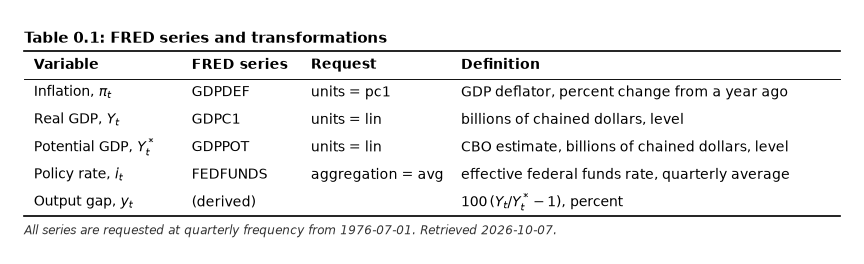

In [10]:
series_table = pd.DataFrame([
    {
        "Variable": r"Inflation, $\pi_t$",
        "FRED series": "GDPDEF",
        "Request": "units = pc1",
        "Definition": "GDP deflator, percent change from a year ago",
    },
    {
        "Variable": r"Real GDP, $Y_t$",
        "FRED series": "GDPC1",
        "Request": "units = lin",
        "Definition": "billions of chained dollars, level",
    },
    {
        "Variable": r"Potential GDP, $Y^*_t$",
        "FRED series": "GDPPOT",
        "Request": "units = lin",
        "Definition": "CBO estimate, billions of chained dollars, level",
    },
    {
        "Variable": r"Policy rate, $i_t$",
        "FRED series": "FEDFUNDS",
        "Request": "aggregation = avg",
        "Definition": "effective federal funds rate, quarterly average",
    },
    {
        "Variable": r"Output gap, $y_t$",
        "FRED series": "(derived)",
        "Request": "",
        "Definition": r"$100\,(Y_t / Y^*_t - 1)$, percent",
    },
]).set_index("Variable")
nb.table(
    series_table,
    "fred_series",
    "FRED series and transformations",
    note=(
        f"All series are requested at quarterly frequency from {cfg.fetch_start}. Retrieved"
        f" {panel.retrieved}."
    ),
)

### Inflation definition and transformation
Inflation is measured as **year-over-year percent change**:

$$
\pi_t = 100 \times \left(\frac{P_t}{P_{t-4}} - 1\right).
$$

The notebook requests this transformation directly from FRED (via units corresponding to YoY percent
change), which reduces implementation variance and makes the transformation explicit at the data-source
layer (Federal Reserve Bank of St. Louis, n.d.).

### Output gap construction
The output gap is defined as the percent deviation of real output from potential output:

$$
y_t = 100 \times \left(\frac{Y_t}{Y_t^\ast} - 1\right).
$$

This ratio-based measure is scale-free and directly interpretable in percentage points, which is
convenient for both regression interpretation and policy simulation (Lütkepohl, 2005).

### Policy indicator
The policy rate $i_t$ is measured using the **effective federal funds rate**, aggregated from monthly to
quarterly frequency by averaging within each quarter to align timing with the quarterly macro series
(Federal Reserve Bank of St. Louis, n.d.).

## Sample windows

The table states the windows every later notebook uses. The TVP model's prior is calibrated on the 40
quarters before the estimation window and those quarters are then discarded, so its estimation sample
starts where the baseline's does.

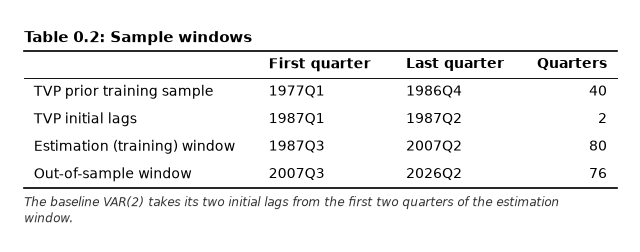

In [11]:
def window_row(frame: pd.DataFrame) -> dict[str, object]:
    return {
        "First quarter": str(frame.index[0]),
        "Last quarter": str(frame.index[-1]),
        "Quarters": len(frame),
    }


tvp_frame = panel.tvp
k_train = cfg.tvp_training_quarters
windows = pd.DataFrame({
    "TVP prior training sample": window_row(tvp_frame.iloc[:k_train]),
    "TVP initial lags": window_row(tvp_frame.iloc[k_train : k_train + cfg.order]),
    "Estimation (training) window": window_row(panel.train),
    "Out-of-sample window": window_row(panel.oos),
}).T
windows["Quarters"] = windows["Quarters"].astype(int)
nb.table(
    windows,
    "sample_windows",
    "Sample windows",
    note=(
        "The baseline VAR(2) takes its two initial lags from the first two quarters of the"
        " estimation window."
    ),
)

### Alignment and integrity checks
The observables are merged into a single quarterly dataset and checked for:
- consistent quarterly indexing,
- expected sample bounds,
- absence of missing values after alignment.

These checks help ensure that subsequent lag construction and estimation are not contaminated by silent
misalignment (pandas development team, 2025). The column order `y, pi, i` is the **recursive ordering**
that every `cultivars` identification below declares.

In [12]:
train, full = panel.train, panel.full
assert train.index[0] == pd.Period(cfg.train_start, "Q") and train.index[-1] == pd.Period(
    cfg.train_end, "Q"
)
assert len(train) == 80, f"expected 80 training quarters, got {len(train)}"
assert list(train.columns) == list(
    af.NAMES
), "column order must be the recursive ordering y, pi, i"
assert not full.isna().any().any()
assert tvp_frame.index[k_train + cfg.order] == pd.Period(cfg.train_start, "Q")
print(
    "Integrity checks passed:",
    len(train),
    "training quarters,",
    len(panel.oos),
    "out-of-sample quarters.",
)

Integrity checks passed: 80 training quarters, 76 out-of-sample quarters.


## The observables

The three model variables over the whole stored history. The shaded band is the estimation window.

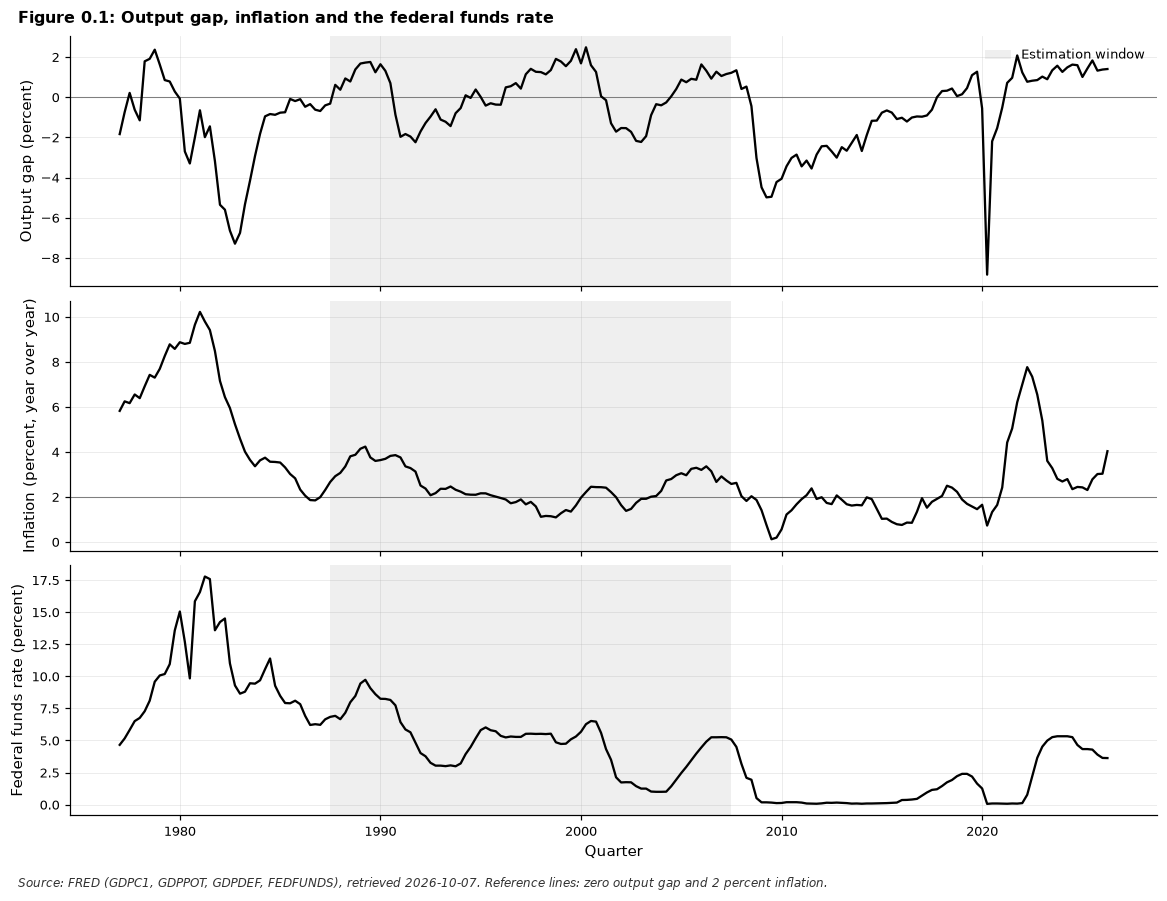

In [13]:
history = panel.data.loc[tvp_frame.index[0] :]
x = plots.timestamps(history.index)

fig, axes = plt.subplots(3, 1, figsize=(10.5, 7.8), sharex=True)
for ax, column, reference in zip(axes, ("y", "pi", "i"), (0.0, 2.0, None)):
    plots.shade_window(ax, cfg.train_start, cfg.train_end, label="Estimation window")
    if reference is not None:
        ax.axhline(reference, color=COLORS["grey"], lw=0.7)
    ax.plot(x, history[column], color=COLORS["black"])
    ax.set_ylabel(plots.VARIABLE_LABELS[column])
axes[-1].set_xlabel("Quarter")
axes[0].legend(loc="upper right")
nb.figure(
    fig,
    "observables",
    "Output gap, inflation and the federal funds rate",
    note=(
        f"Source: FRED (GDPC1, GDPPOT, GDPDEF, FEDFUNDS), retrieved {panel.retrieved}. "
        "Reference lines: zero output gap and 2 percent inflation."
    ),
)

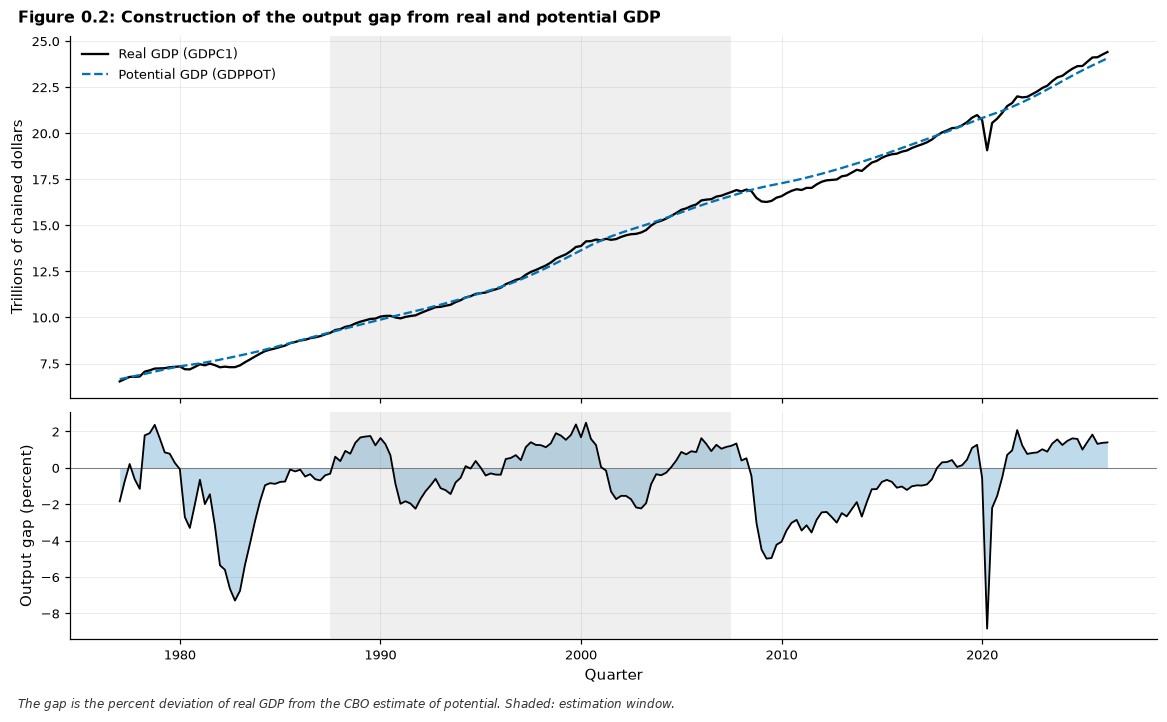

In [14]:
fig, (ax_level, ax_gap) = plt.subplots(
    2, 1, figsize=(10.5, 6.2), sharex=True, height_ratios=[1.6, 1]
)
ax_level.plot(x, history["gdp_real"] / 1e3, color=COLORS["black"], label="Real GDP (GDPC1)")
ax_level.plot(
    x,
    history["gdp_potential"] / 1e3,
    color=COLORS["blue"],
    ls="--",
    label="Potential GDP (GDPPOT)",
)
ax_level.set_ylabel("Trillions of chained dollars")
ax_level.legend(loc="upper left")
ax_gap.axhline(0.0, color=COLORS["grey"], lw=0.7)
ax_gap.fill_between(x, history["y"], 0.0, color=COLORS["blue"], alpha=0.25, lw=0)
ax_gap.plot(x, history["y"], color=COLORS["black"], lw=1.2)
ax_gap.set_ylabel(plots.VARIABLE_LABELS["y"])
ax_gap.set_xlabel("Quarter")
for ax in (ax_level, ax_gap):
    plots.shade_window(ax, cfg.train_start, cfg.train_end)
nb.figure(
    fig,
    "output_gap_construction",
    "Construction of the output gap from real and potential GDP",
    note=(
        "The gap is the percent deviation of real GDP from the CBO estimate of potential."
        " Shaded: estimation window."
    ),
)

## Descriptive statistics

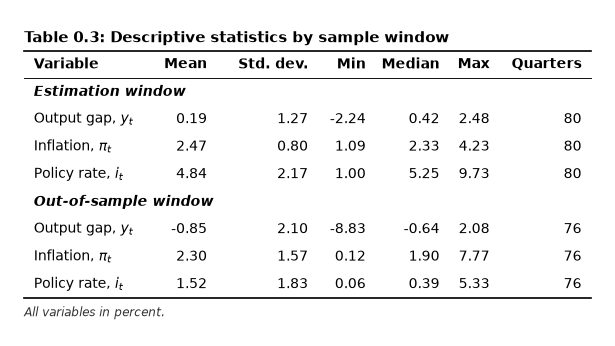

In [15]:
LABELS = {"y": r"Output gap, $y_t$", "pi": r"Inflation, $\pi_t$", "i": r"Policy rate, $i_t$"}
stats_rows = {}
for window_label, frame in (
    ("Estimation window", panel.train),
    ("Out-of-sample window", panel.oos),
):
    described = frame.describe().T
    for column in af.NAMES:
        stats_rows[(window_label, LABELS[column])] = {
            "Mean": described.at[column, "mean"],
            "Std. dev.": described.at[column, "std"],
            "Min": described.at[column, "min"],
            "Median": described.at[column, "50%"],
            "Max": described.at[column, "max"],
            "Quarters": int(described.at[column, "count"]),
        }
stats_table = pd.DataFrame.from_dict(stats_rows, orient="index")
stats_table.index = pd.MultiIndex.from_tuples(stats_table.index, names=["Window", "Variable"])
nb.table(
    stats_table,
    "descriptive_statistics",
    "Descriptive statistics by sample window",
    float_format="{:.2f}",
    note="All variables in percent.",
)

# References (APA)

## Software

1. Sunder, N. (2026). cultivars: Research-grade time series econometrics for Python (v1.0.0a1). https://pypi.org/project/cultivars/
2. Sunder, N. (2025). fedfred: A Python client for the Federal Reserve Economic Database (FRED) API (v3.0.0). Zenodo. https://doi.org/10.5281/zenodo.17635942
3. The pandas development team. (2026). pandas-dev/pandas: Pandas. Zenodo. https://doi.org/10.5281/zenodo.18675244
4. Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., Fernández del Río, J., Wiebe, M., Peterson, P., Gérard-Marchant, P., Sheppard, K., Reddy, T., Weckesser, W., Abbasi, H., Gohlke, C., & Oliphant, T. E. (2020). Array programming with NumPy. *Nature*, 585(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2
5. Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., Burovski, E., Peterson, P., Weckesser, W., Bright, J., van der Walt, S. J., Brett, M., Wilson, J., Millman, K. J., Mayorov, N., Nelson, A. R. J., Jones, E., Kern, R., Larson, E., … SciPy 1.0 Contributors. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods*, 17, 261–272. https://doi.org/10.1038/s41592-019-0686-2
6. The Matplotlib Development Team. (2025). Matplotlib: Visualization with Python. Zenodo. https://doi.org/10.5281/zenodo.17595503
7. Seabold, S., & Perktold, J. (2010). statsmodels: Econometric and statistical modeling with Python. In *Proceedings of the 9th Python in Science Conference* (pp. 92–96). https://doi.org/10.25080/Majora-92bf1922-011
8. Kluyver, T., Ragan-Kelley, B., Pérez, F., Granger, B., Bussonnier, M., Frederic, J., Kelley, K., Hamrick, J., Grout, J., Corlay, S., Ivanov, P., Avila, D., Abdalla, S., Willing, C., & Jupyter Development Team. (2016). Jupyter Notebooks – a publishing format for reproducible computational workflows. In *Positioning and Power in Academic Publishing: Players, Agents and Agendas* (pp. 87–90). IOS Press. https://doi.org/10.3233/978-1-61499-649-1-87
9. Python Software Foundation. (2025). Python (Version 3.13) [Computer software]. https://www.python.org/

## Papers & Books

1. Hinterlang, N., & Tänzer, A. (2021). Optimal monetary policy using reinforcement learning. *SSRN*. https://doi.org/10.2139/ssrn.4013384
2. Sims, C. A. (1980). Macroeconomics and reality. *Econometrica*, 48(1), 1–48. https://doi.org/10.2307/1912017
3. Lütkepohl, H. (2005). *New introduction to multiple time series analysis*. Springer. https://doi.org/10.1007/3-540-27752-8
4. Clements, M. P., & Hendry, D. F. (1998). *Forecasting economic time series*. Cambridge University Press. https://doi.org/10.1017/CBO9780511599286
5. Stock, J. H., & Watson, M. W. (2007). Why has U.S. inflation become harder to forecast? *Journal of Money, Credit and Banking*, 39(s1), 3–33. https://doi.org/10.1111/j.1538-4616.2007.00014.x
6. Cogley, T., & Sargent, T. J. (2005). Drifts and volatilities: Monetary policies and outcomes in the post WWII US. *Review of Economic Dynamics*, 8(2), 262–302. https://doi.org/10.1016/j.red.2004.10.009
7. Primiceri, G. E. (2005). Time varying structural vector autoregressions and monetary policy. *Review of Economic Studies*, 72(3), 821–852. https://doi.org/10.1111/j.1467-937X.2005.00353.x
8. Hamilton, J. D. (1994). *Time series analysis*. Princeton University Press.
9. Giacomini, R., & White, H. (2006). Tests of conditional predictive ability. *Econometrica*, 74(6), 1545–1578. https://doi.org/10.1111/j.1468-0262.2006.00718.x
10. Carter, C. K., & Kohn, R. (1994). On Gibbs sampling for state space models. *Biometrika*, 81(3), 541–553. https://doi.org/10.1093/biomet/81.3.541
11. Kim, S., Shephard, N., & Chib, S. (1998). Stochastic volatility: Likelihood inference and comparison with ARCH models. *Review of Economic Studies*, 65(3), 361–393. https://doi.org/10.1111/1467-937X.00050
12. Kim, C.-J., & Nelson, C. R. (1999). *State-space models with regime switching: Classical and Gibbs-sampling approaches with applications*. MIT Press.
13. Diebold, F. X., & Mariano, R. S. (1995). Comparing predictive accuracy. *Journal of Business & Economic Statistics*, 13(3), 253–263. https://doi.org/10.1080/07350015.1995.10524599
14. Harvey, D., Leybourne, S., & Newbold, P. (1997). Testing the equality of prediction mean squared errors. *International Journal of Forecasting*, 13(2), 281–291. https://doi.org/10.1016/S0169-2070(96)00719-4
15. Hansen, P. R., Lunde, A., & Nason, J. M. (2011). The model confidence set. *Econometrica*, 79(2), 453–497. https://doi.org/10.3982/ECTA5771
16. Mincer, J., & Zarnowitz, V. (1969). The evaluation of economic forecasts. In J. Mincer (Ed.), *Economic forecasts and expectations: Analysis of forecasting behavior and performance* (pp. 3–46). NBER.
17. Waggoner, D. F., & Zha, T. (1999). Conditional forecasts in dynamic multivariate models. *Review of Economics and Statistics*, 81(4), 639–651. https://doi.org/10.1162/003465399558508
18. Federal Reserve Bank of St. Louis. (n.d.). *Federal Reserve Economic Data (FRED)*. https://fred.stlouisfed.org/

# Export

The last cell converts this notebook to PDF in the shared `documents/` directory. A kernel can only
convert the copy saved on disk, so the cell waits briefly for the editor to save; if the file is still
behind, it writes nothing and asks you to save and run it again.

In [16]:
nb.export_pdf()

/var/folders/cj/p5jdwnb923752l7zjc_69j5w0000gn/T/ipykernel_76252/281924391.py:1: UserWarning: 00_data.ipynb on disk does not yet contain this run's outputs, so no PDF was written. Save the notebook and run this cell again.
  nb.export_pdf()
